In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math
from scipy.stats import pearsonr

In [17]:
df = pd.read_csv("Tiktok Data After EDA.csv")
df.head()

,username,created_at,likes,comments,shares,views,engagement_rate,post_date,posts_per_day,views_per_video,likes_per_video,comments_per_video,hour,weekday
0,661._miaa,2024-09-16 17:56:17+00:00,183900,329,3361,826700,0.226914,2024-09-16,1,826700.0,183900.0,329.0,17,Monday
1,nightmoonxyz,2025-04-23 04:25:50+00:00,2391,99,118,48600,0.053663,2025-04-23,1,48600.0,2391.0,99.0,4,Wednesday
2,fyp,2025-12-24 18:18:20+00:00,1504,16,21,42700,0.036089,2025-12-24,1,42700.0,1504.0,16.0,18,Wednesday
3,ljubicaastevic,2025-08-21 23:49:04+00:00,744,83,44,33600,0.025923,2025-08-21,1,33600.0,744.0,83.0,23,Thursday
4,franncchii,2025-03-14 03:31:55+00:00,1633,106,59,136400,0.013182,2025-03-14,1,136400.0,1633.0,106.0,3,Friday


In [18]:
df.columns

Index(['username', 'created_at', 'likes', 'comments', 'shares', 'views',
       'engagement_rate', 'post_date', 'posts_per_day', 'views_per_video',
       'likes_per_video', 'comments_per_video', 'hour', 'weekday'],
      dtype='object')

In [19]:
import pandas as pd

# ensure datetime
df['post_date'] = pd.to_datetime(df['post_date'])

# posts per day
df['posts_per_day'] = (
    df.groupby(df['post_date'].dt.date)['post_date']
    .transform('count')
)

# posts per week
df['posts_per_week'] = (
    df.groupby(df['post_date'].dt.to_period('W'))['post_date']
    .transform('count')
)

# posts per month
df['posts_per_month'] = (
    df.groupby(df['post_date'].dt.to_period('M'))['post_date']
    .transform('count')
)

# posts per year
df['posts_per_year'] = (
    df.groupby(df['post_date'].dt.to_period('Y'))['post_date']
    .transform('count')
)

df.head()


,username,created_at,likes,comments,shares,views,engagement_rate,post_date,posts_per_day,views_per_video,likes_per_video,comments_per_video,hour,weekday,posts_per_week,posts_per_month,posts_per_year
0,661._miaa,2024-09-16 17:56:17+00:00,183900,329,3361,826700,0.226914,2024-09-16,1,826700.0,183900.0,329.0,17,Monday,2,8,56
1,nightmoonxyz,2025-04-23 04:25:50+00:00,2391,99,118,48600,0.053663,2025-04-23,3,48600.0,2391.0,99.0,4,Wednesday,6,21,542
2,fyp,2025-12-24 18:18:20+00:00,1504,16,21,42700,0.036089,2025-12-24,21,42700.0,1504.0,16.0,18,Wednesday,138,229,542
3,ljubicaastevic,2025-08-21 23:49:04+00:00,744,83,44,33600,0.025923,2025-08-21,4,33600.0,744.0,83.0,23,Thursday,11,31,542
4,franncchii,2025-03-14 03:31:55+00:00,1633,106,59,136400,0.013182,2025-03-14,1,136400.0,1633.0,106.0,3,Friday,2,19,542


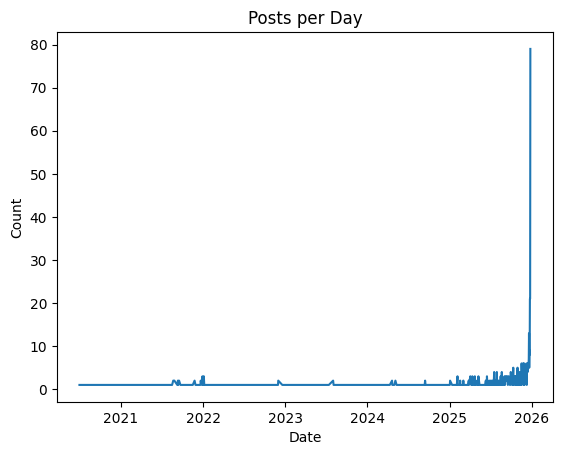

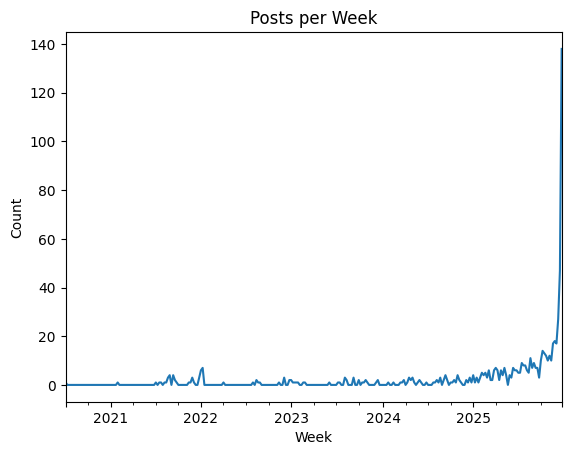

C:\Users\Ahmed\AppData\Local\Temp\ipykernel_26692\3279510081.py:26: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  posts_per_month = df.set_index('post_date').resample('M').size()


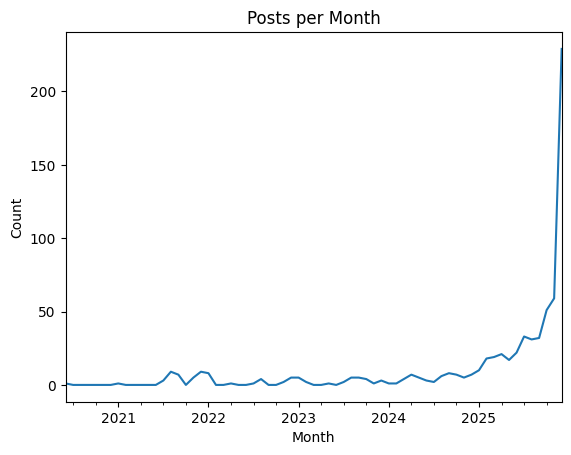

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# ensure datetime
df['post_date'] = pd.to_datetime(df['post_date'])

# ---- Posts per day ----
posts_per_day = df.groupby(df['post_date'].dt.date).size()
plt.figure()
posts_per_day.plot()
plt.title("Posts per Day")
plt.xlabel("Date")
plt.ylabel("Count")
plt.show()

# ---- Posts per week ----
posts_per_week = df.set_index('post_date').resample('W').size()
plt.figure()
posts_per_week.plot()
plt.title("Posts per Week")
plt.xlabel("Week")
plt.ylabel("Count")
plt.show()

# ---- Posts per month ----
posts_per_month = df.set_index('post_date').resample('M').size()
plt.figure()
posts_per_month.plot()
plt.title("Posts per Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()


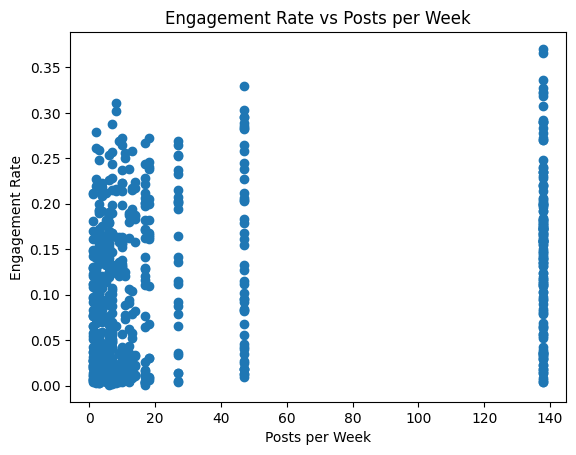

In [54]:
plt.figure()
plt.scatter(df['posts_per_week'], df['engagement_rate'])
plt.xlabel('Posts per Week')
plt.ylabel('Engagement Rate')
plt.title('Engagement Rate vs Posts per Week')
plt.show()


(0.0, 0.2)

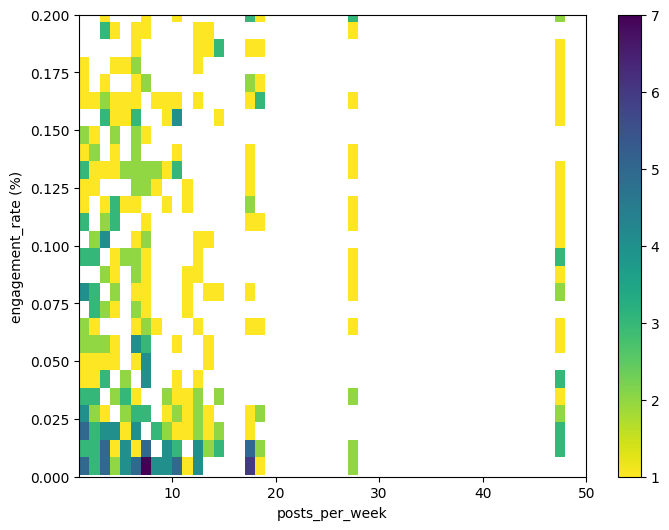

In [25]:
plt.figure(figsize = [18, 6])

plt.subplot(1, 2, 2)

# Use actual data range for bins
bins_x = np.linspace(df['posts_per_week'].min(), 50, 50)
bins_y = np.linspace(df['engagement_rate'].min(), df['engagement_rate'].max(), 50)

plt.hist2d(data = df, x = 'posts_per_week', y = 'engagement_rate', 
           cmin=0.5, cmap='viridis_r', bins = [bins_x, bins_y])
plt.colorbar()
plt.xlabel('posts_per_week')
plt.ylabel('engagement_rate (%)')

plt.ylim(0, 0.2) 



(0.0, 1500000.0)

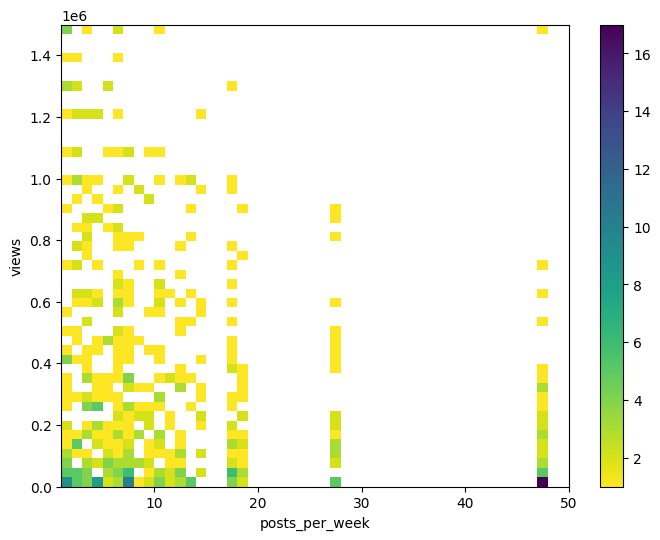

In [56]:
plt.figure(figsize = [18, 6])

plt.subplot(1, 2, 2)

# Use actual data range for bins
bins_x = np.linspace(df['posts_per_week'].min(), 50, 50)
bins_y = np.linspace(df['views'].min(), df['views'].max(), 50)

plt.hist2d(data = df, x = 'posts_per_week', y = 'views', 
           cmin=0.5, cmap='viridis_r', bins = [bins_x, bins_y])
plt.colorbar()
plt.xlabel('posts_per_week')
plt.ylabel('views')

plt.ylim(0, df['views'].max()) 



In [35]:
df['engagement_bin'] = pd.cut(df['engagement_rate'], bins=np.linspace(0, 0.2,3 ))


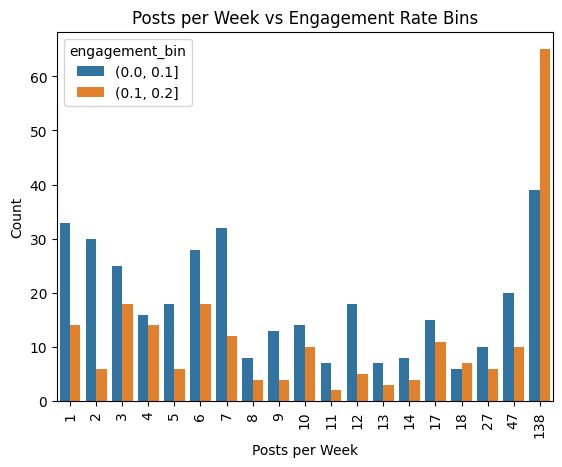

In [37]:

sns.countplot(data=df, x='posts_per_week', hue='engagement_bin')
plt.xlabel('Posts per Week')
plt.ylabel('Count')
plt.title('Posts per Week vs Engagement Rate Bins')
plt.xticks(rotation=90)
plt.show()

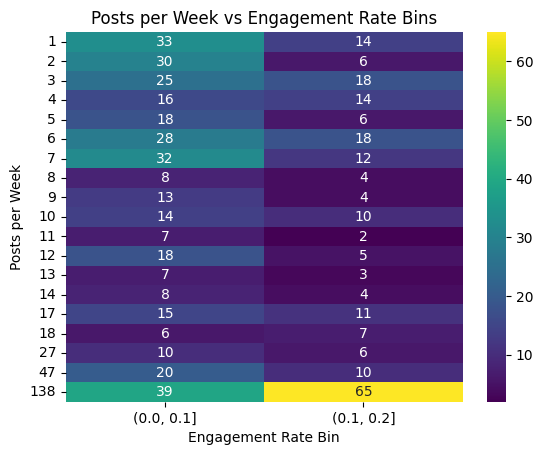

In [44]:
ct = pd.crosstab(df['posts_per_week'], df['engagement_bin'])

# Heatmap
sns.heatmap(ct, annot=True, fmt='d', cmap='viridis')
plt.xlabel('Engagement Rate Bin')
plt.ylabel('Posts per Week')
plt.title('Posts per Week vs Engagement Rate Bins')
plt.show()

(0.0, 0.3)

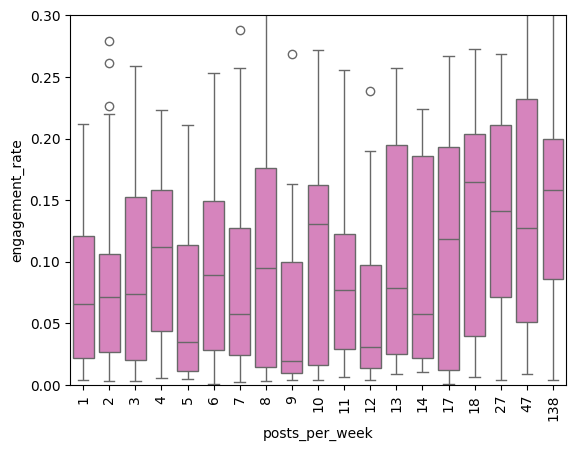

In [50]:
base_color = sns.color_palette()[6]
sns.boxplot(data=df, x='posts_per_week', y='engagement_rate', color=base_color)
plt.xticks(rotation=90);
plt.ylim(0,0.3)

Regression Equation: engagement_rate = 0.000468 * posts_per_week + 0.091335
Slope: 0.000468 (change in engagement rate per post per week)
Intercept: 0.091335 (baseline engagement rate at 0 posts/week)
R-squared: 0.0806


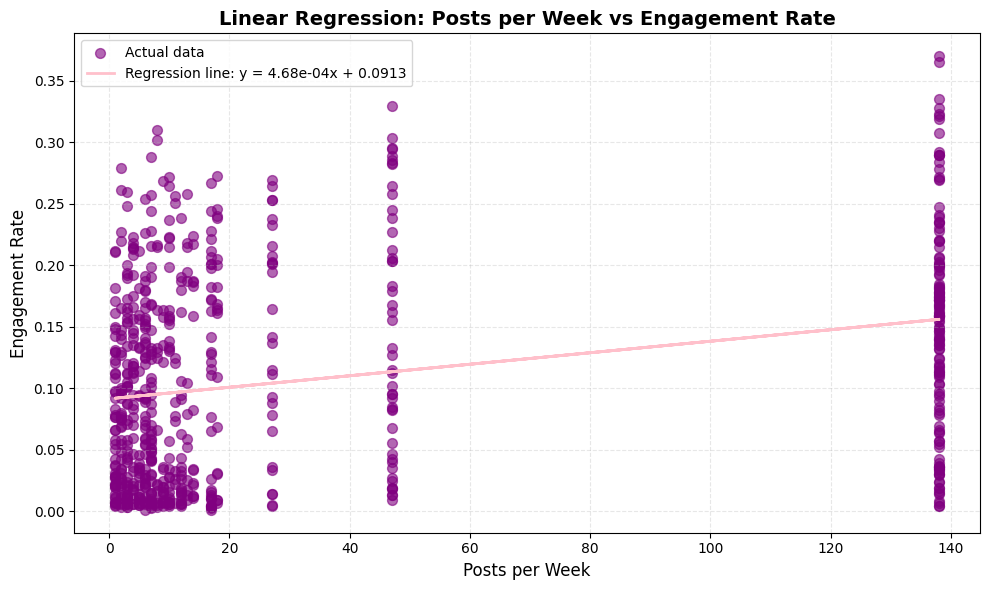


INTERPRETATION:
Positive slope (0.000468): As posts per week increase by 1, engagement rate increases by 0.000468.
R-squared of 0.0806 means that 8.1% of the variation in engagement rate can be explained by posts per week.


In [53]:
x = df[['posts_per_week']]  # 2D array
y = df['engagement_rate']   # engagement rate

# Linear regression
model = LinearRegression()
model.fit(x, y)

# Slope and intercept
slope = model.coef_[0]
intercept = model.intercept_
r_squared = model.score(X, y)

print(f"Regression Equation: engagement_rate = {slope:.6f} * posts_per_week + {intercept:.6f}")
print(f"Slope: {slope:.6f} (change in engagement rate per post per week)")
print(f"Intercept: {intercept:.6f} (baseline engagement rate at 0 posts/week)")
print(f"R-squared: {r_squared:.4f}")

# Predict values for plotting
y_pred = model.predict(x)

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.6, s=50, color='purple', label='Actual data')  # scatter points
plt.plot(x, y_pred, color='pink', linewidth=2, label=f'Regression line: y = {slope:.2e}x + {intercept:.4f}')  # regression line

plt.xlabel('Posts per Week', fontsize=12)
plt.ylabel('Engagement Rate', fontsize=12)
plt.title('Linear Regression: Posts per Week vs Engagement Rate', fontsize=14, fontweight='bold')

plt.grid(alpha=0.3, linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

# Interpretation
print("\n" + "="*50)
print("INTERPRETATION:")
if slope < 0:
    print(f"Negative slope ({slope:.6f}): As posts per week increase by 1, engagement rate decreases by {abs(slope):.6f}.")
else:
    print(f"Positive slope ({slope:.6f}): As posts per week increase by 1, engagement rate increases by {slope:.6f}.")
print(f"R-squared of {r_squared:.4f} means that {r_squared*100:.1f}% of the variation in engagement rate can be explained by posts per week.")
print("="*50)
